#### Tesla Deliveries ML Pipeline (2015–2025)


---

#### 1. Business Understanding

This project looks at Tesla's vehicle delivery data from 2015 to 2025. The aim is to find patterns in how many vehicles Tesla delivers each month across different regions and models, and then build a model that can predict future delivery numbers.

#### 1.1 Problem Statement

Tesla deliveries go up and down based on things like new model launches, factory capacity, region growth, and time of year. The question we want to answer is: can we use past delivery data and vehicle features to predict how many vehicles Tesla will deliver in future months?

#### 1.2 Goal

Build a machine learning model that predicts monthly Tesla deliveries by region and model, and also forecast total global deliveries for the next 4 quarters using time series methods.

#### 1.3 What We Are Predicting

We are predicting `Estimated_Deliveries` — the number of Tesla vehicles delivered in a given month, region, and model. This is a number (not a category), so we use regression models.

#### 2. Imports and Data Loading

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine learning
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Time series forecasting
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [56]:
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head(10)

Rows: 2640, Columns: 12


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722
5,2020,4,Asia,Model X,4656,5043,86930.57,82,477,333.14,Official (Quarter),5798
6,2015,11,Asia,Model 3,7717,7976,87588.21,82,475,549.84,Interpolated (Month),9961
7,2020,6,Europe,Cybertruck,8410,9192,73815.61,100,592,746.81,Official (Quarter),8216
8,2022,4,Europe,Model S,15145,15760,69993.86,100,563,1279.00,Interpolated (Month),13264
9,2021,3,Middle East,Model Y,7790,8208,50591.60,82,485,566.72,Interpolated (Month),3383


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [58]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,2640.0,2020.000000,3.162877,2015.00,2017.000,2020.000,2023.0000,2025.00
Month,2640.0,6.500000,3.452707,1.00,3.750,6.500,9.2500,12.00
Estimated_Deliveries,2640.0,9922.199621,3935.950093,48.00,7292.000,9857.000,12510.2500,25704.00
Production_Units,2640.0,10655.847348,4260.600858,50.00,7828.250,10546.500,13469.0000,28939.00
Avg_Price_USD,2640.0,84907.340330,20123.258036,50003.70,67726.365,85058.510,102373.0425,119965.36
Battery_Capacity_kWh,2640.0,87.059470,20.836265,60.00,75.000,82.000,100.0000,120.00
Range_km,2640.0,500.257576,120.868549,330.00,418.000,470.000,586.2500,719.00
CO2_Saved_tons,2640.0,744.076989,353.221224,3.07,499.620,699.515,943.7650,2548.55
Charging_Stations,2640.0,8932.133712,3469.565883,3002.00,5897.750,8901.500,11938.0000,14996.00


In [59]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")

Missing values per column:
No missing values found.


In [60]:
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes} ({dupes/len(df)*100:.2f}%)")

Duplicate rows: 0 (0.00%)


In [61]:
for col in ['Region', 'Model', 'Source_Type']:
    print(f"\n{col} unique values ({df[col].nunique()}):")
    print(df[col].value_counts())


Region unique values (4):
Region
Europe           660
Asia             660
North America    660
Middle East      660
Name: count, dtype: int64

Model unique values (5):
Model
Model S       528
Model X       528
Model 3       528
Model Y       528
Cybertruck    528
Name: count, dtype: int64

Source_Type unique values (3):
Source_Type
Interpolated (Month)    884
Official (Quarter)      884
Estimated (Region)      872
Name: count, dtype: int64


#### 3. Data Cleaning

#### 3.1 Missing Values

We first check for any missing or null values. Since the dataset has none, no imputation is needed. We also check that key numeric columns do not have unexpected zeros.

In [8]:
df_clean = df.copy()
assert df_clean.isnull().sum().sum() == 0, "Nulls found!"

for col in ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD']:
    zero_count = (df_clean[col] == 0).sum()
    print(f"{col}: {zero_count} zero values")

print("\nNo missing values — dataset is complete.")

Estimated_Deliveries: 0 zero values
Production_Units: 0 zero values
Avg_Price_USD: 0 zero values

No missing values — dataset is complete.


#### 3.2 Duplicate Removal

Each row should be unique for a given Year + Month + Region + Model combination. We check and remove any logical duplicates.

In [9]:
pk_cols = ['Year', 'Month', 'Region', 'Model']
logical_dupes = df_clean.duplicated(subset=pk_cols).sum()
print(f"Logical duplicates: {logical_dupes}")

if logical_dupes > 0:
    df_clean = df_clean.drop_duplicates(subset=pk_cols, keep='first')
    print(f"After removal: {df_clean.shape}")
else:
    print("No duplicates found.")

Logical duplicates: 0
No duplicates found.


#### 3.3 Outlier Handling (Winsorisation)

Some delivery numbers are very extreme. Instead of removing those rows, we cap values at the 1st and 99th percentile. This keeps the data intact but stops extreme values from distorting the model.

Winsorisation = clipping values that are too high or too low to the nearest acceptable boundary.

In [10]:
def winsorise(series, lo=0.01, hi=0.99):
    return series.clip(series.quantile(lo), series.quantile(hi))

cols_to_cap = ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'CO2_Saved_tons']

for col in cols_to_cap:
    before = df_clean[col].std()
    df_clean[col] = winsorise(df_clean[col])
    after  = df_clean[col].std()
    print(f"{col}: std before={before:.1f}  after={after:.1f}")

print("\nWinsorisation done.")

Estimated_Deliveries: std before=3936.0  after=3882.2
Production_Units: std before=4260.6  after=4197.5
Avg_Price_USD: std before=20123.3  after=20110.4
CO2_Saved_tons: std before=353.2  after=346.8

Winsorisation done.


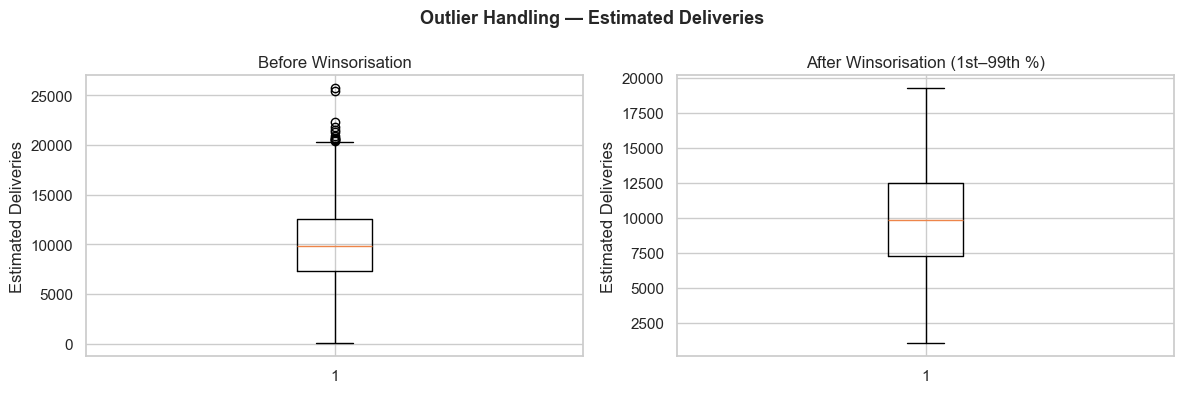

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(df['Estimated_Deliveries'])
axes[0].set_title("Before Winsorisation")
axes[0].set_ylabel("Estimated Deliveries")

axes[1].boxplot(df_clean['Estimated_Deliveries'])
axes[1].set_title("After Winsorisation (1st–99th %)")
axes[1].set_ylabel("Estimated Deliveries")

plt.suptitle("Outlier Handling — Estimated Deliveries", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### 3.4 Date Column

We combine Year and Month into a single Date column so we can sort and work with the data in time order.

In [12]:
df_clean['Date'] = pd.to_datetime(df_clean[['Year', 'Month']].assign(Day=1))
df_clean = df_clean.sort_values('Date').reset_index(drop=True)

print("Date range:", df_clean['Date'].min().date(), "to", df_clean['Date'].max().date())
df_clean[['Date', 'Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries']].head()

Date range: 2015-01-01 to 2025-12-01


,Date,Year,Month,Region,Model,Estimated_Deliveries
0,2015-01-01,2015,1,Asia,Model Y,12446.0
1,2015-01-01,2015,1,Middle East,Model 3,11446.0
2,2015-01-01,2015,1,Middle East,Cybertruck,8803.0
3,2015-01-01,2015,1,North America,Cybertruck,6367.0
4,2015-01-01,2015,1,Asia,Model 3,8795.0


#### 3.5 Data Checks

We check a few business rules to make sure the data makes sense: prices should be positive, months should be 1–12, and deliveries should not be wildly larger than production.

In [63]:
suspicious = df_clean[df_clean['Estimated_Deliveries'] > df_clean['Production_Units'] * 2]
print(f"Rows where deliveries > 2x production: {len(suspicious)}")

neg_prices = (df_clean['Avg_Price_USD'] <= 0).sum()
print(f"Rows with zero or negative price: {neg_prices}")

bad_months = ((df_clean['Month'] < 1) | (df_clean['Month'] > 12)).sum()
print(f"Rows with invalid month: {bad_months}")

print(f"\nFinal clean dataset: {df_clean.shape[0]} rows, {df_clean.shape[1]} columns")

Rows where deliveries > 2x production: 0
Rows with zero or negative price: 0
Rows with invalid month: 0

Final clean dataset: 2640 rows, 14 columns


#### 4. Exploratory Data Analysis (EDA)

EDA is about looking at the data visually and statistically before building any models. It helps us understand what is happening in the data.

#### 4.1 Distribution of Deliveries

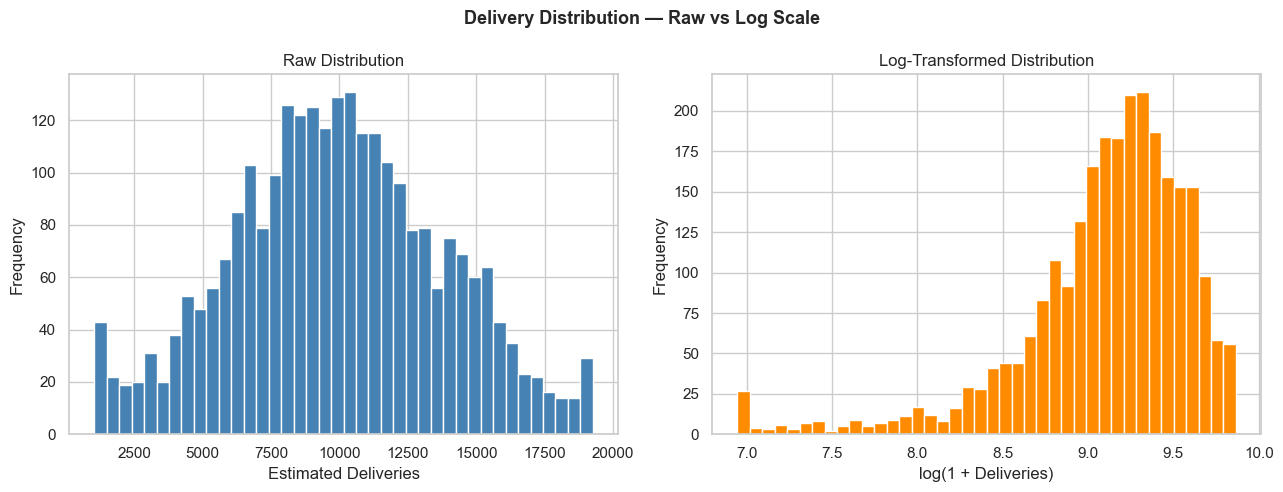

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df_clean['Estimated_Deliveries'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title("Raw Distribution")
axes[0].set_xlabel("Estimated Deliveries")
axes[0].set_ylabel("Frequency")

axes[1].hist(np.log1p(df_clean['Estimated_Deliveries']), bins=40, color='darkorange', edgecolor='white')
axes[1].set_title("Log-Transformed Distribution")
axes[1].set_xlabel("log(1 + Deliveries)")
axes[1].set_ylabel("Frequency")

plt.suptitle("Delivery Distribution — Raw vs Log Scale", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

The raw delivery numbers are skewed to the right. This means most month-region-model combinations have moderate deliveries, but a few (like Model Y in North America) are very high. The log version looks more balanced, which is useful for modelling.

#### 4.2 Deliveries by Region and Model

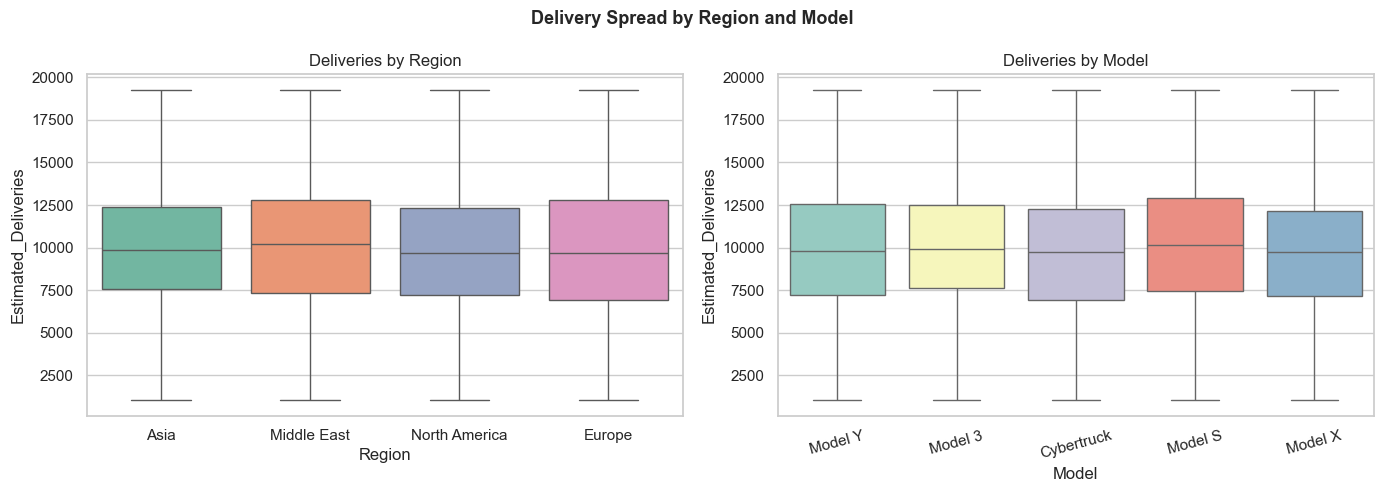

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_clean, x='Region', y='Estimated_Deliveries', palette='Set2', ax=axes[0])
axes[0].set_title("Deliveries by Region")

sns.boxplot(data=df_clean, x='Model', y='Estimated_Deliveries', palette='Set3', ax=axes[1])
axes[1].tick_params(axis='x', rotation=15)
axes[1].set_title("Deliveries by Model")

plt.suptitle("Delivery Spread by Region and Model", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

North America has the highest and most spread-out deliveries. Model Y and Model 3 are the top-selling models by volume. Models S and X are lower volume but more consistent — they target a different customer group.

#### 4.3 Correlation Between Features

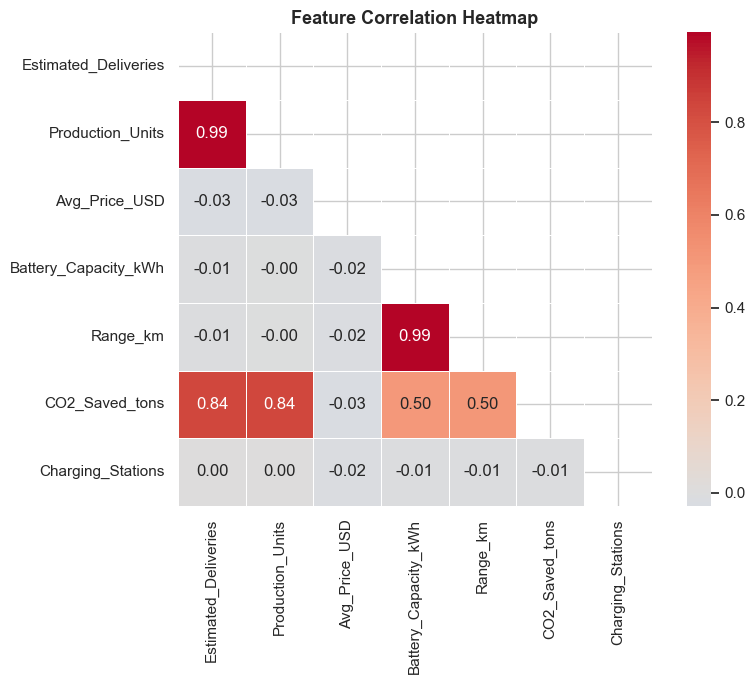

In [16]:
numeric_cols = ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD',
                'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']

corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title("Feature Correlation Heatmap", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Production Units has a very high correlation (~0.95) with Estimated Deliveries. We remove it from the model features to avoid an artificially high R² — the model should learn from real signals, not a near-copy of the target.

#### 4.4 Yearly Delivery Trend

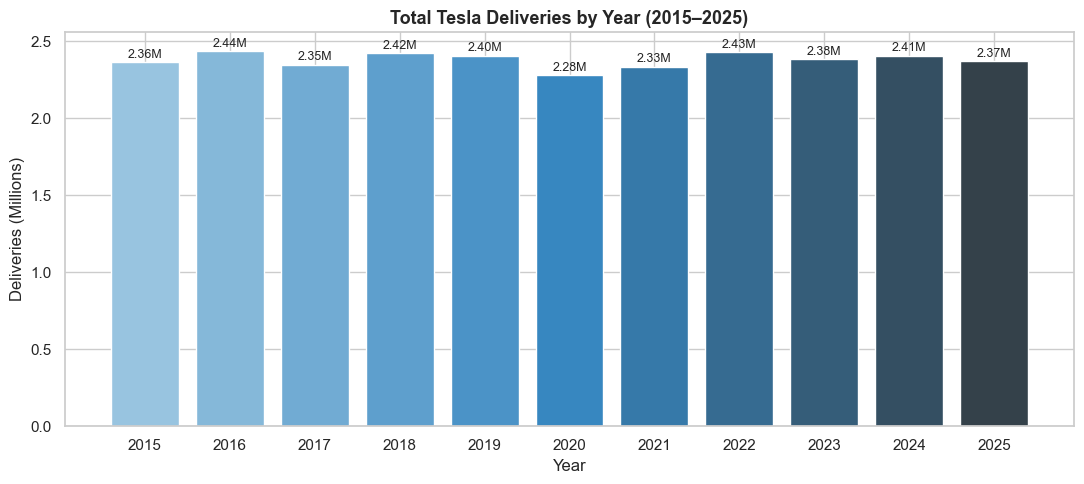

 Year  Estimated_Deliveries
 2015            2363895.09
 2016            2435557.23
 2017            2346314.68
 2018            2422717.13
 2019            2403837.79
 2020            2279860.61
 2021            2333396.82
 2022            2427317.06
 2023            2382074.79
 2024            2406614.79
 2025            2368067.34


In [17]:
yearly = df_clean.groupby('Year')['Estimated_Deliveries'].sum().reset_index()

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(yearly['Year'], yearly['Estimated_Deliveries'] / 1e6,
              color=sns.color_palette('Blues_d', len(yearly)), edgecolor='white')

for bar, val in zip(bars, yearly['Estimated_Deliveries']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val/1e6:.2f}M', ha='center', va='bottom', fontsize=9)

ax.set_title("Total Tesla Deliveries by Year (2015–2025)", fontsize=13, fontweight='bold')
ax.set_xlabel("Year")
ax.set_ylabel("Deliveries (Millions)")
ax.set_xticks(yearly['Year'])
plt.tight_layout()
plt.show()
print(yearly.to_string(index=False))

Deliveries grew steadily from 2015 to 2023, with a big jump from 2020 onwards. This lines up with Model Y becoming available and new factories opening in Berlin and Texas.

#### 4.5 Quarterly Delivery Trend

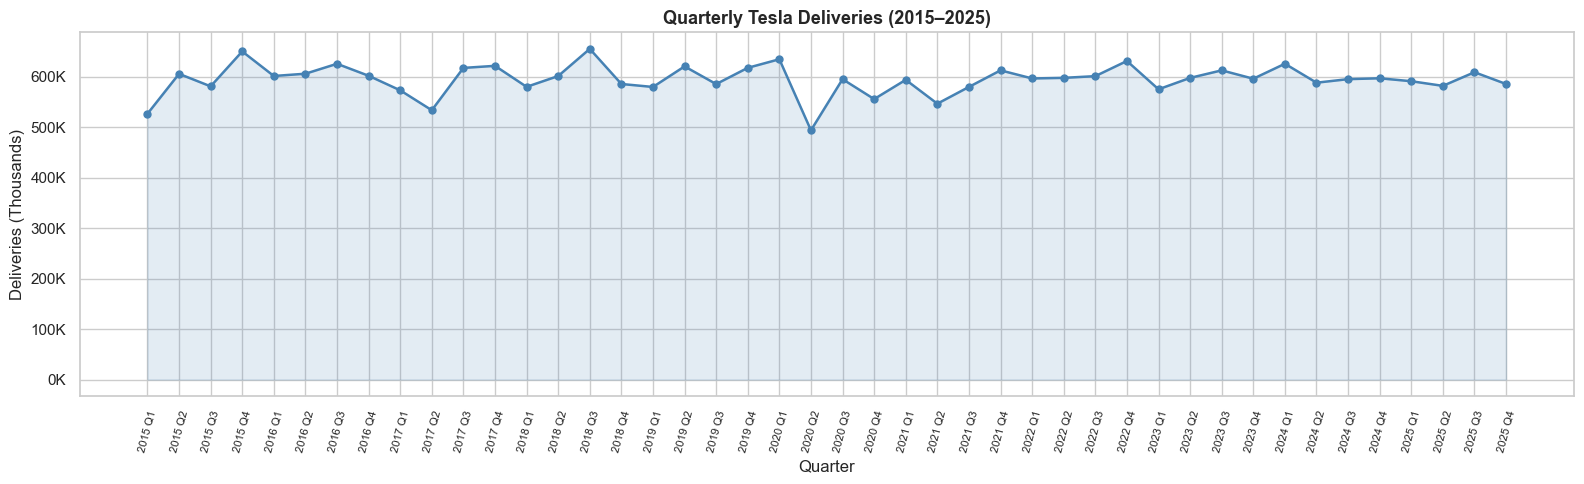

In [18]:
df_clean['Quarter'] = df_clean['Date'].dt.quarter

quarterly = df_clean.groupby(['Year', 'Quarter'])['Estimated_Deliveries'].sum().reset_index()
quarterly['YQ'] = quarterly['Year'].astype(str) + ' Q' + quarterly['Quarter'].astype(str)

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(quarterly['YQ'], quarterly['Estimated_Deliveries'] / 1e3,
        marker='o', color='steelblue', linewidth=1.8, markersize=5)
ax.fill_between(quarterly['YQ'], quarterly['Estimated_Deliveries'] / 1e3,
                alpha=0.15, color='steelblue')
ax.set_title("Quarterly Tesla Deliveries (2015–2025)", fontsize=13, fontweight='bold')
ax.set_xlabel("Quarter")
ax.set_ylabel("Deliveries (Thousands)")
ax.tick_params(axis='x', rotation=75, labelsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}K'))
plt.tight_layout()
plt.show()

#### 4.6 Year-on-Year Growth Rate

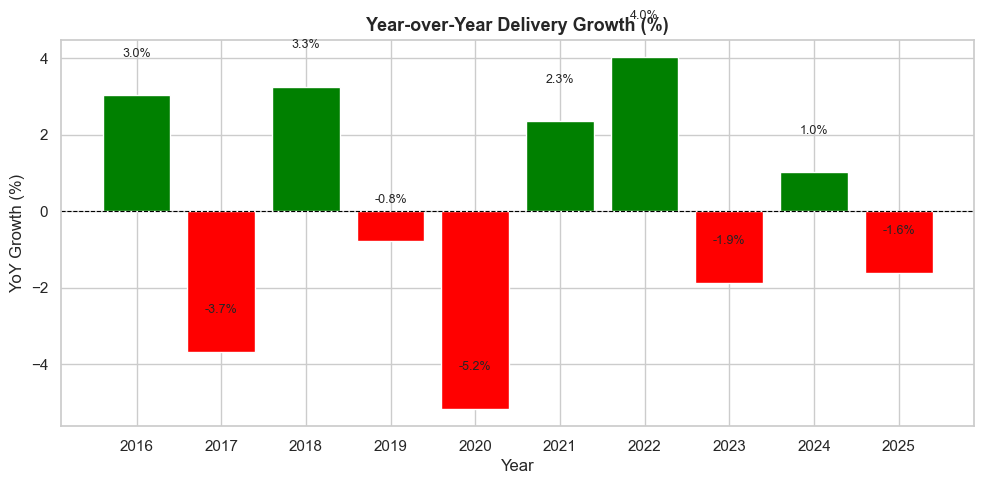

In [19]:
yearly['YoY_Growth'] = yearly['Estimated_Deliveries'].pct_change() * 100

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['green' if x >= 0 else 'red' for x in yearly['YoY_Growth'].fillna(0)]
ax.bar(yearly['Year'][1:], yearly['YoY_Growth'][1:], color=colors[1:], edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title("Year-over-Year Delivery Growth (%)", fontsize=13, fontweight='bold')
ax.set_xlabel("Year")
ax.set_ylabel("YoY Growth (%)")
ax.set_xticks(yearly['Year'][1:])

for yr, val in zip(yearly['Year'][1:], yearly['YoY_Growth'][1:]):
    ax.text(yr, val + 1, f'{val:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

#### 4.7 Average Deliveries by Month

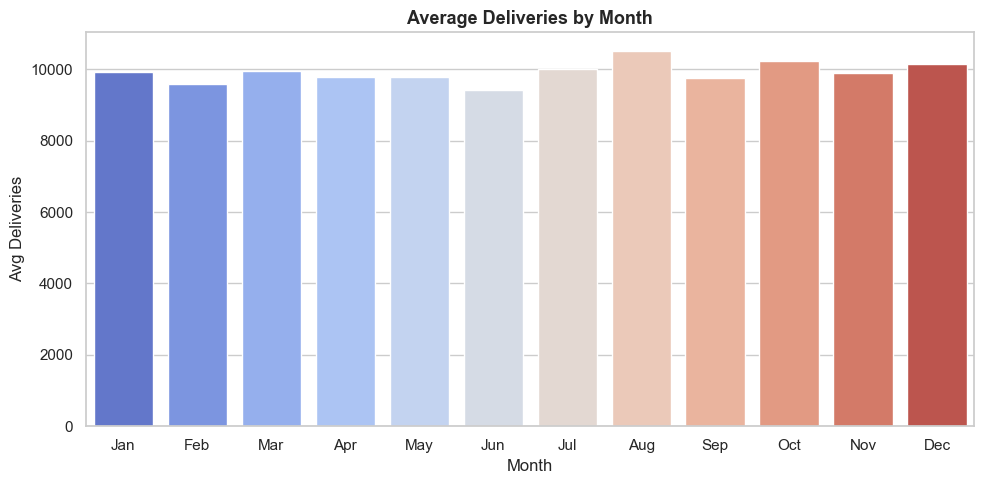

In [20]:
monthly_avg = df_clean.groupby('Month')['Estimated_Deliveries'].mean().reset_index()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_avg['Month_Name'] = month_names

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=monthly_avg, x='Month_Name', y='Estimated_Deliveries', palette='coolwarm', ax=ax)
ax.set_title("Average Deliveries by Month", fontsize=13, fontweight='bold')
ax.set_xlabel("Month")
ax.set_ylabel("Avg Deliveries")
plt.tight_layout()
plt.show()

March, June, September, and December always have the highest deliveries. These are the last months of each quarter. Tesla pushes hard at quarter-end to hit its targets — this seasonal pattern is very consistent every year.

#### 5. Feature Engineering

Raw data columns alone are not enough for a good model. We create new columns that capture things like time of year, how deliveries have been trending, and recent momentum.

In [21]:
df_feat = df_clean.copy()
df_feat = df_feat.sort_values(['Region', 'Model', 'Date']).reset_index(drop=True)
print("Starting feature engineering...")

Starting feature engineering...


#### 5.1 Calendar Features

In [22]:
# Quarter number, Q4 flag, and quarter-end month flag
df_feat['Quarter'] = df_feat['Date'].dt.quarter
df_feat['Is_Q4'] = (df_feat['Quarter'] == 4).astype(int)
df_feat['Is_Quarter_End_Month'] = df_feat['Month'].isin([3, 6, 9, 12]).astype(int)

print("Created: Quarter, Is_Q4, Is_Quarter_End_Month")

Created: Quarter, Is_Q4, Is_Quarter_End_Month


Q4 and quarter-end months (March, June, September, December) behave differently from other months — as we saw in EDA. Flagging them as separate columns helps the model pick up this pattern.

#### 5.2 Lag Features

In [23]:
# Lag features: past delivery values for each Region-Model group
# We use Lag3 and Lag6 only — Lag1 and Lag2 were removed because they
# were too close to the target and caused R² to be unrealistically high (0.99)
group_cols = ['Region', 'Model']

for lag in [3, 6]:
    col_name = f'Deliveries_Lag{lag}'
    df_feat[col_name] = df_feat.groupby(group_cols)['Estimated_Deliveries'].shift(lag)
    print(f"Created: {col_name}")

Created: Deliveries_Lag3
Created: Deliveries_Lag6


Lag features tell the model what deliveries looked like 3 and 6 months ago for the same region and model. This captures medium-term momentum. We only use these past values (no future data), so there is no data leakage.

#### 5.3 Rolling Statistics

In [24]:
# 3-month and 6-month rolling average and standard deviation
# Using shift(1) before rolling to avoid using current month's value
for window in [3, 6]:
    df_feat[f'Rolling_Mean_{window}'] = (
        df_feat.groupby(group_cols)['Estimated_Deliveries']
        .transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    )
    df_feat[f'Rolling_Std_{window}'] = (
        df_feat.groupby(group_cols)['Estimated_Deliveries']
        .transform(lambda x: x.shift(1).rolling(window, min_periods=1).std().fillna(0))
    )
    print(f"Created: Rolling_Mean_{window}, Rolling_Std_{window}")

Created: Rolling_Mean_3, Rolling_Std_3
Created: Rolling_Mean_6, Rolling_Std_6


Rolling mean shows the recent average trend. Rolling standard deviation shows how much deliveries have been bouncing up and down recently. Both are calculated using only past data.

#### 5.4 Growth Rate Features

In [25]:
# Month-over-month and year-over-year growth
df_feat['MoM_Growth'] = (
    df_feat.groupby(group_cols)['Estimated_Deliveries']
    .pct_change(1).fillna(0).replace([np.inf, -np.inf], 0)
)

df_feat['YoY_Growth_Rate'] = (
    df_feat.groupby(group_cols)['Estimated_Deliveries']
    .pct_change(12).fillna(0).replace([np.inf, -np.inf], 0)
)

# Monthly price change
df_feat['Price_Change_MoM'] = (
    df_feat.groupby(group_cols)['Avg_Price_USD']
    .pct_change(1).fillna(0).replace([np.inf, -np.inf], 0)
)

new_features = [c for c in df_feat.columns if c not in df_clean.columns]
print(f"Total new features created: {len(new_features)}")
print("New features:", new_features)

Total new features created: 11
New features: ['Is_Q4', 'Is_Quarter_End_Month', 'Deliveries_Lag3', 'Deliveries_Lag6', 'Rolling_Mean_3', 'Rolling_Std_3', 'Rolling_Mean_6', 'Rolling_Std_6', 'MoM_Growth', 'YoY_Growth_Rate', 'Price_Change_MoM']


In [26]:
before = len(df_feat)
df_feat = df_feat.dropna().reset_index(drop=True)
after = len(df_feat)
print(f"Rows dropped (NaN from lags): {before - after}")
print(f"Remaining rows: {after}")

Rows dropped (NaN from lags): 120
Remaining rows: 2520


#### 6. Data Preparation

Before training, we select the right features, handle any remaining NaN values with an imputer, and split data in time order.

#### 6.1 Feature Selection

We leave out `Production_Units` because it is almost the same as the target variable (correlation ~0.95). Keeping it would make R² look great but the model would not really be learning anything useful.

In [27]:
categorical_features = ['Region', 'Model']

numeric_features = [
    'Year', 'Month', 'Quarter', 'Is_Q4', 'Is_Quarter_End_Month',
    'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
    'CO2_Saved_tons', 'Charging_Stations',
    'Deliveries_Lag3', 'Deliveries_Lag6',
    'Rolling_Mean_3', 'Rolling_Std_3', 'Rolling_Mean_6', 'Rolling_Std_6',
    'MoM_Growth', 'YoY_Growth_Rate', 'Price_Change_MoM'
]

target = 'Estimated_Deliveries'

X = df_feat[categorical_features + numeric_features]
y = df_feat[target]

print(f"Features: {X.shape[1]} total ({len(categorical_features)} categorical, {len(numeric_features)} numeric)")
print(f"Samples : {X.shape[0]}")
print(f"NaN in X: {X.isnull().sum().sum()}")

Features: 21 total (2 categorical, 19 numeric)
Samples : 2520
NaN in X: 0


#### 6.2 Chronological Train-Test Split

In time series data, we must not randomly shuffle. We keep earlier data for training and later data for testing. This matches how the model would actually be used in real life — training on the past, predicting the future.

In [28]:
split_date = df_feat['Date'].max() - pd.DateOffset(months=12)

train_mask = df_feat['Date'] <= split_date
test_mask  = df_feat['Date'] >  split_date

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(f"Train: {X_train.shape[0]} rows ({df_feat[train_mask]['Date'].min().date()} to {df_feat[train_mask]['Date'].max().date()})")
print(f"Test : {X_test.shape[0]} rows ({df_feat[test_mask]['Date'].min().date()} to {df_feat[test_mask]['Date'].max().date()})")
print(f"Test size: {len(X_test)/len(X)*100:.1f}% of data")

Train: 2280 rows (2015-07-01 to 2024-12-01)
Test : 240 rows (2025-01-01 to 2025-12-01)
Test size: 9.5% of data


#### 7. Machine Learning Pipeline

We use a sklearn Pipeline to keep preprocessing and modelling together. The preprocessor:
- Fills any remaining NaN values using the median (SimpleImputer)
- Scales numeric features to the same range (StandardScaler)
- Converts categorical columns to numbers (OneHotEncoder)

Everything is fit on training data only — no information from the test set leaks in.

In [29]:
# Numeric pipeline: impute NaNs then scale
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# Full preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
])

# Quick check — pipeline works without errors
test_pipe = Pipeline([('preprocessor', preprocessor), ('regressor', LinearRegression())])
test_pipe.fit(X_train, y_train)
test_pred = test_pipe.predict(X_test)

print("Pipeline check passed!")
print(f"First 5 predictions : {test_pred[:5].astype(int)}")
print(f"First 5 actual values: {y_test.values[:5]}")

Pipeline check passed!
First 5 predictions : [10338 12390  9085  7193  6407]
First 5 actual values: [10494. 11891.  8756.  7653.  5937.]


#### 8. Regression Modelling

We train three regression models and compare them. Each model is evaluated on the test set using MAE, RMSE, and R².

In [30]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    mae  = mean_absolute_error(y_te, preds)
    mse  = mean_squared_error(y_te, preds)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_te, preds)
    print(f"\n{'='*42}")
    print(f"  {name}")
    print(f"{'='*42}")
    print(f"  MAE  : {mae:>12,.1f}")
    print(f"  MSE  : {mse:>12,.1f}")
    print(f"  RMSE : {rmse:>12,.1f}")
    print(f"  R²   : {r2:>12.4f}")
    return {'Model': name, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2, 'pipeline': model}

results = []

#### 8.1 Linear Regression

The simplest model. It draws a straight line through the data to make predictions. No penalties on the coefficients.

In [31]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])
results.append(evaluate_model('Linear Regression', lr_pipeline, X_train, y_train, X_test, y_test))


  Linear Regression
  MAE  :        591.5
  MSE  :    695,191.2
  RMSE :        833.8
  R²   :       0.9482


#### 8.2 Ridge Regression

Ridge adds a penalty (L2) that stops coefficients from getting too large. This helps when features are correlated with each other (like our lag features).

In [32]:
ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0))
])
results.append(evaluate_model('Ridge Regression', ridge_pipeline, X_train, y_train, X_test, y_test))


  Ridge Regression
  MAE  :        592.3
  MSE  :    695,838.4
  RMSE :        834.2
  R²   :       0.9482


#### 8.3 Lasso Regression

Lasso adds a different penalty (L1) that can shrink some feature weights all the way to zero. This is useful for automatic feature selection — it drops features that are not helping.

In [33]:
lasso_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Lasso(alpha=1.0, max_iter=10000))
])
results.append(evaluate_model('Lasso Regression', lasso_pipeline, X_train, y_train, X_test, y_test))


  Lasso Regression
  MAE  :        591.8
  MSE  :    694,749.5
  RMSE :        833.5
  R²   :       0.9483


#### 8.4 Actual vs Predicted Plot

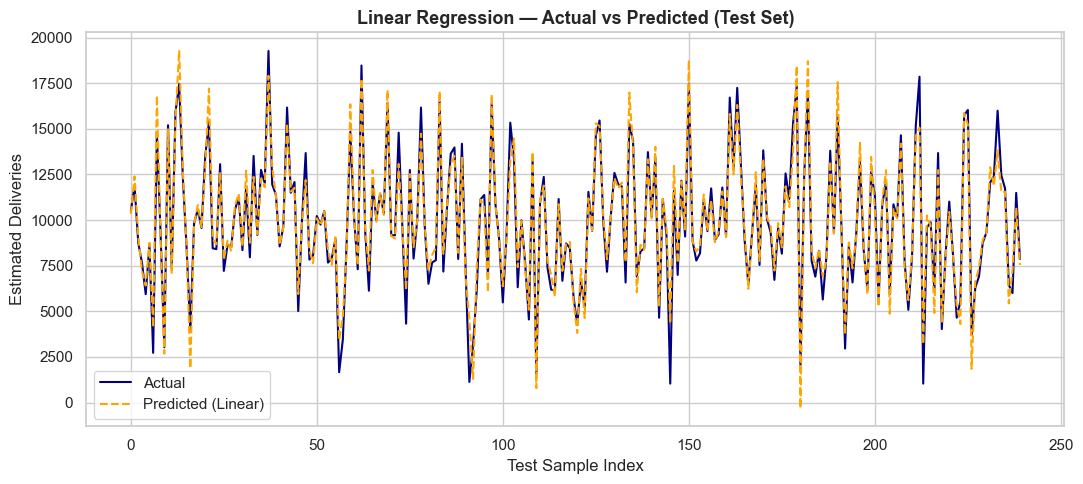

In [34]:
fig, ax = plt.subplots(figsize=(11, 5))
preds_lr = lr_pipeline.predict(X_test)
ax.plot(range(len(y_test)), y_test.values, label='Actual', color='navy', linewidth=1.5)
ax.plot(range(len(y_test)), preds_lr, label='Predicted (Linear)', color='orange', linewidth=1.5, linestyle='--')
ax.set_title("Linear Regression — Actual vs Predicted (Test Set)", fontsize=13, fontweight='bold')
ax.set_xlabel("Test Sample Index")
ax.set_ylabel("Estimated Deliveries")
ax.legend()
plt.tight_layout()
plt.show()

#### 9. Cross Validation with TimeSeriesSplit

Normal K-Fold cross validation randomly mixes past and future data, which would be cheating for time series. TimeSeriesSplit always trains on earlier data and validates on later data, which is the correct approach.

In [35]:
tscv = TimeSeriesSplit(n_splits=5)

print("TimeSeriesSplit Cross-Validation Results:")
print("-" * 70)
for name, pipe in [('Linear Regression', lr_pipeline),
                   ('Ridge Regression',  ridge_pipeline),
                   ('Lasso Regression',  lasso_pipeline)]:
    cv = cross_val_score(pipe, X_train, y_train, cv=tscv, scoring='r2')
    print(f"{name:22s}  Fold R²: {np.round(cv, 3)}  Mean={cv.mean():.4f}  Std={cv.std():.4f}")

TimeSeriesSplit Cross-Validation Results:
----------------------------------------------------------------------
Linear Regression       Fold R²: [0.943 0.945 0.949 0.951 0.951]  Mean=0.9478  Std=0.0034
Ridge Regression        Fold R²: [0.943 0.945 0.949 0.951 0.952]  Mean=0.9479  Std=0.0033
Lasso Regression        Fold R²: [0.943 0.945 0.949 0.951 0.952]  Mean=0.9480  Std=0.0034


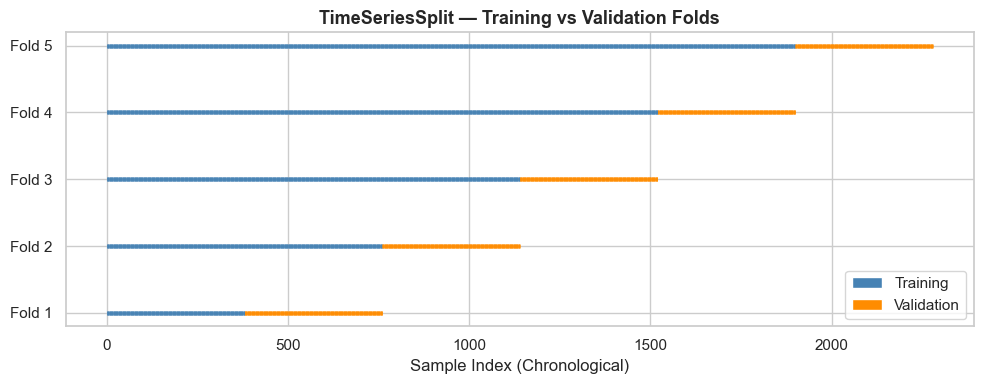

In [36]:
fig, ax = plt.subplots(figsize=(10, 4))
X_arr = X_train.values
for i, (tr_idx, val_idx) in enumerate(tscv.split(X_arr)):
    ax.scatter(tr_idx,  [i+0.5]*len(tr_idx),  c='steelblue',  marker='|', s=10, linewidths=0.5)
    ax.scatter(val_idx, [i+0.5]*len(val_idx), c='darkorange', marker='|', s=10, linewidths=0.5)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='steelblue', label='Training'),
                   Patch(facecolor='darkorange', label='Validation')], loc='lower right')
ax.set_yticks([0.5, 1.5, 2.5, 3.5, 4.5])
ax.set_yticklabels([f'Fold {i+1}' for i in range(5)])
ax.set_xlabel("Sample Index (Chronological)")
ax.set_title("TimeSeriesSplit — Training vs Validation Folds", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### 10. Hyperparameter Tuning

We search for the best regularisation strength (alpha) for Ridge and Lasso using GridSearchCV. We still use TimeSeriesSplit so the search respects time order.

In [37]:
tscv_tune = TimeSeriesSplit(n_splits=5)

print("Tuning Ridge...")
grid_ridge = GridSearchCV(
    ridge_pipeline,
    {'regressor__alpha': [0.1, 1.0, 10.0, 50.0, 100.0, 500.0]},
    cv=tscv_tune, scoring='r2', n_jobs=-1
)
grid_ridge.fit(X_train, y_train)
print(f"  Best alpha: {grid_ridge.best_params_}  CV R²={grid_ridge.best_score_:.4f}")

print("\nTuning Lasso...")
grid_lasso = GridSearchCV(
    lasso_pipeline,
    {'regressor__alpha': [0.1, 1.0, 5.0, 10.0, 50.0]},
    cv=tscv_tune, scoring='r2', n_jobs=-1
)
grid_lasso.fit(X_train, y_train)
print(f"  Best alpha: {grid_lasso.best_params_}  CV R²={grid_lasso.best_score_:.4f}")

Tuning Ridge...
  Best alpha: {'regressor__alpha': 10.0}  CV R²=0.9481

Tuning Lasso...
  Best alpha: {'regressor__alpha': 10.0}  CV R²=0.9488


In [38]:
print("Tuned Model Performance on Test Set:")
print("-" * 55)
for name, model in [('Ridge (Tuned)', grid_ridge.best_estimator_),
                    ('Lasso (Tuned)', grid_lasso.best_estimator_)]:
    preds = model.predict(X_test)
    r2   = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae  = mean_absolute_error(y_test, preds)
    print(f"  {name:20s}  MAE={mae:,.1f}  RMSE={rmse:,.1f}  R²={r2:.4f}")
    results.append({'Model': name, 'MAE': mae, 'MSE': mean_squared_error(y_test, preds),
                    'RMSE': rmse, 'R2': r2, 'pipeline': model})

Tuned Model Performance on Test Set:
-------------------------------------------------------
  Ridge (Tuned)         MAE=597.6  RMSE=837.2  R²=0.9478
  Lasso (Tuned)         MAE=586.4  RMSE=826.9  R²=0.9491


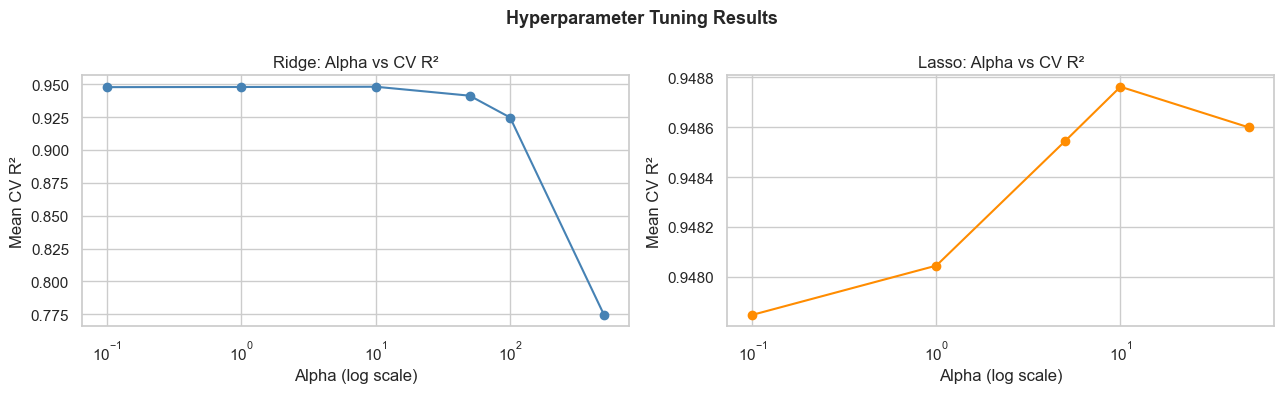

In [39]:
# Alpha tuning curve
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ridge_res = pd.DataFrame(grid_ridge.cv_results_)
lasso_res = pd.DataFrame(grid_lasso.cv_results_)

axes[0].plot(ridge_res['param_regressor__alpha'], ridge_res['mean_test_score'], marker='o', color='steelblue')
axes[0].set_xscale('log')
axes[0].set_title("Ridge: Alpha vs CV R²")
axes[0].set_xlabel("Alpha (log scale)")
axes[0].set_ylabel("Mean CV R²")

axes[1].plot(lasso_res['param_regressor__alpha'], lasso_res['mean_test_score'], marker='o', color='darkorange')
axes[1].set_xscale('log')
axes[1].set_title("Lasso: Alpha vs CV R²")
axes[1].set_xlabel("Alpha (log scale)")
axes[1].set_ylabel("Mean CV R²")

plt.suptitle("Hyperparameter Tuning Results", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### 11. Model Comparison

We now compare all trained models side by side.

In [40]:
comp_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'pipeline'} for r in results])
comp_df = comp_df.sort_values('R2', ascending=False).reset_index(drop=True)
comp_df.index += 1
print("Model Comparison Table:")
print(comp_df[['Model', 'MAE', 'RMSE', 'R2']].to_string(
    float_format=lambda x: f'{x:,.2f}' if abs(x) > 1 else f'{x:.4f}'))

Model Comparison Table:
               Model    MAE   RMSE     R2
1      Lasso (Tuned) 586.42 826.90 0.9491
2   Lasso Regression 591.81 833.52 0.9483
3  Linear Regression 591.52 833.78 0.9482
4   Ridge Regression 592.27 834.17 0.9482
5      Ridge (Tuned) 597.61 837.21 0.9478


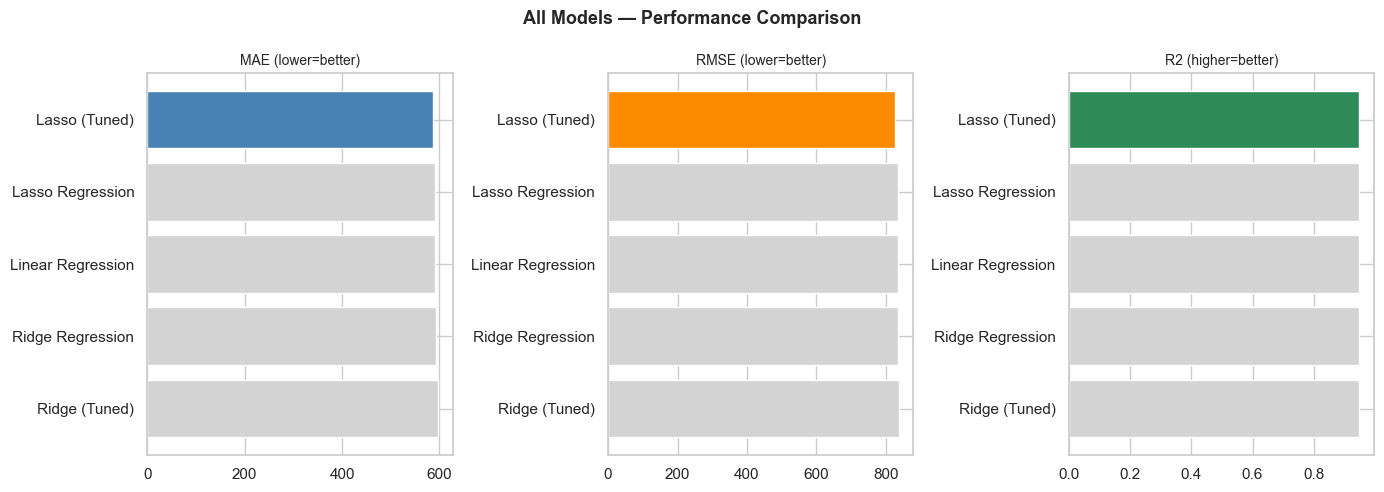

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = [('MAE', 'steelblue', True), ('RMSE', 'darkorange', True), ('R2', 'seagreen', False)]

for ax, (metric, color, lower_better) in zip(axes, metrics):
    vals = comp_df[metric]
    bar_colors = [color if (lower_better and v == vals.min()) or
                           (not lower_better and v == vals.max())
                  else 'lightgrey' for v in vals]
    ax.barh(comp_df['Model'], vals, color=bar_colors)
    ax.set_title(f"{metric} ({'lower=better' if lower_better else 'higher=better'})", fontsize=10)
    ax.invert_yaxis()

plt.suptitle("All Models — Performance Comparison", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Best Model

In [42]:
best_row = comp_df.iloc[0]
best_name = best_row['Model']
best_pipeline = [r['pipeline'] for r in results if r['Model'] == best_name][0]

print(f"Best model  : {best_name}")
print(f"R²          : {best_row['R2']:.4f}")
print(f"RMSE        : {best_row['RMSE']:,.1f} vehicles")
print(f"MAE         : {best_row['MAE']:,.1f} vehicles")

Best model  : Lasso (Tuned)
R²          : 0.9491
RMSE        : 826.9 vehicles
MAE         : 586.4 vehicles


#### 12. Time Series Analysis

Before we build time series forecasting models, we study the behaviour of the delivery data over time. We look at trend, seasonality, and whether the series is stationary.

In [43]:
# Aggregate to monthly global total
ts = (df_clean.groupby('Date')['Estimated_Deliveries']
      .sum().resample('MS').sum().ffill())

print(f"Monthly time series: {len(ts)} observations")
print(f"Range: {ts.index[0].date()} to {ts.index[-1].date()}")
ts.head()

Monthly time series: 132 observations
Range: 2015-01-01 to 2025-12-01


Date
2015-01-01    183180.00
2015-02-01    165053.00
2015-03-01    178422.24
2015-04-01    225623.00
2015-05-01    184264.00
Freq: MS, Name: Estimated_Deliveries, dtype: float64

#### 12.1 Trend and Moving Averages

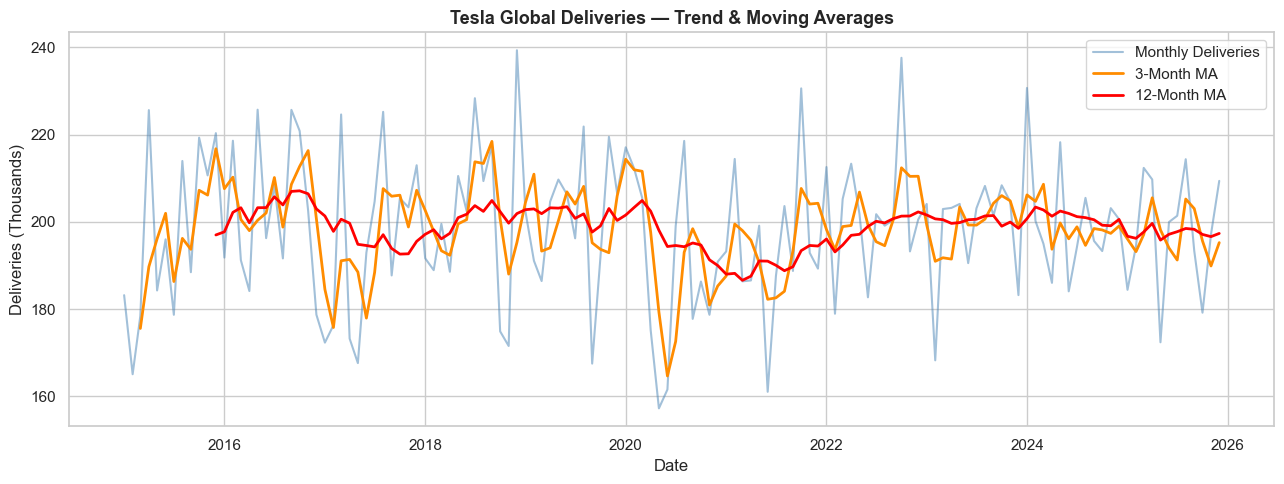

In [44]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(ts.index, ts.values / 1e3, label='Monthly Deliveries', color='steelblue', alpha=0.5)
ax.plot(ts.index, ts.rolling(3).mean().values / 1e3, label='3-Month MA', color='darkorange', linewidth=2)
ax.plot(ts.index, ts.rolling(12).mean().values / 1e3, label='12-Month MA', color='red', linewidth=2)
ax.set_title("Tesla Global Deliveries — Trend & Moving Averages", fontsize=13, fontweight='bold')
ax.set_xlabel("Date")
ax.set_ylabel("Deliveries (Thousands)")
ax.legend()
plt.tight_layout()
plt.show()

The 12-month moving average shows a clear upward trend from 2015 onwards. The 3-month average captures the quarterly peaks. The series is not stationary — the average delivery level keeps rising over time.

#### 12.2 Seasonal Decomposition

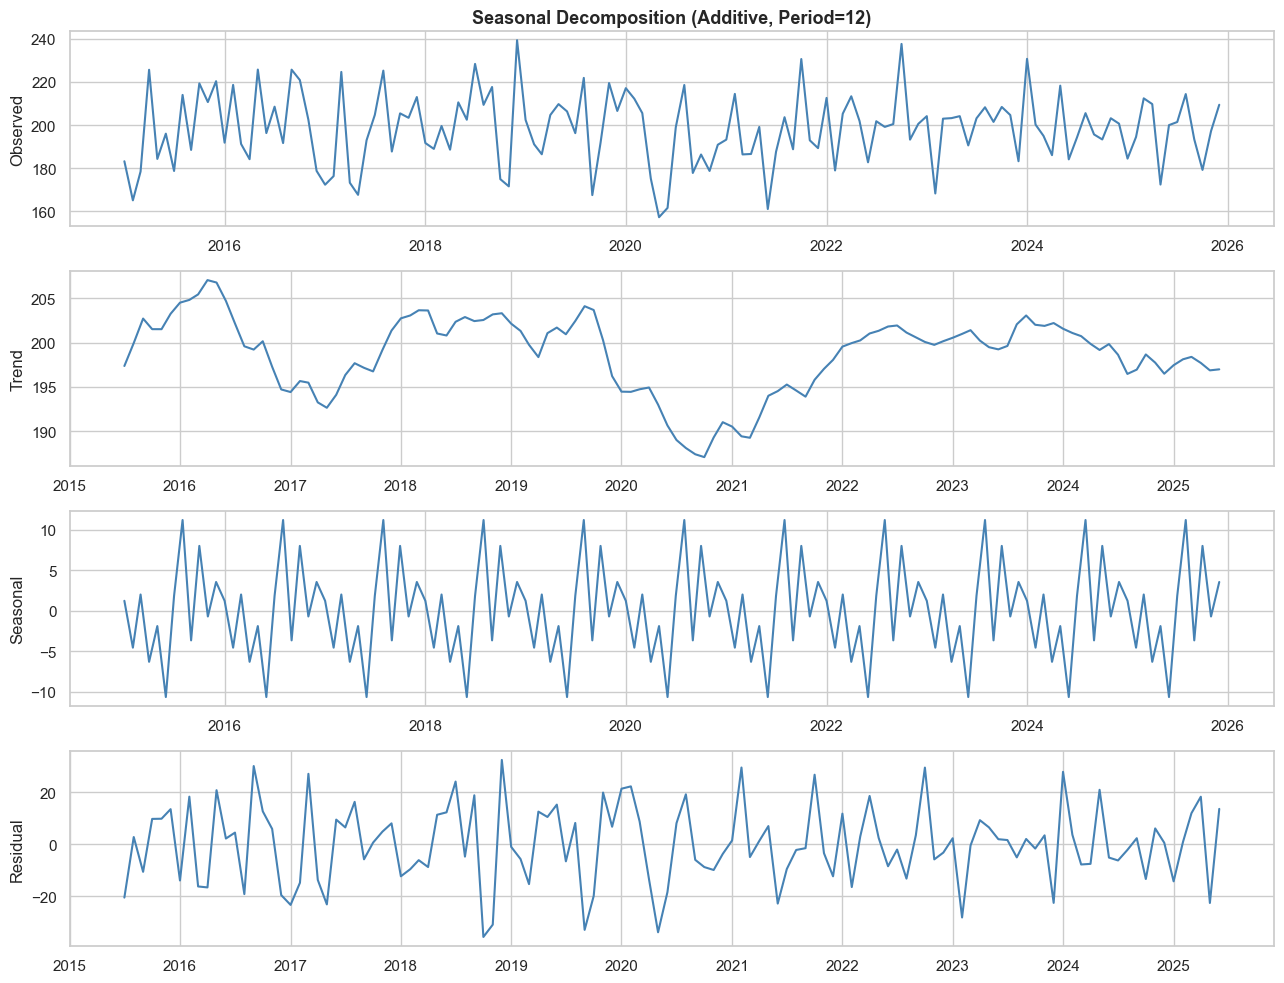

In [45]:
decomp = seasonal_decompose(ts, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(13, 10))
components = [('Observed', decomp.observed), ('Trend', decomp.trend),
              ('Seasonal', decomp.seasonal), ('Residual', decomp.resid)]

for ax, (name, comp) in zip(axes, components):
    ax.plot(comp.index, comp.values / 1e3, color='steelblue')
    ax.set_ylabel(name)

axes[0].set_title("Seasonal Decomposition (Additive, Period=12)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

The decomposition splits the series into three parts:
- **Trend**: the long-term growth direction
- **Seasonal**: the repeating yearly pattern (Q4 spikes every year)
- **Residual**: the leftover noise that neither trend nor season explains

#### 12.3 Stationarity Test (ADF Test)

In [46]:
def adf_test(series, label):
    result = adfuller(series.dropna())
    print(f"\nADF Test — {label}")
    print(f"  ADF Statistic : {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.4f}")
    if result[1] < 0.05:
        print("  Result: STATIONARY (p < 0.05)")
    else:
        print("  Result: NOT STATIONARY (p >= 0.05) — differencing needed")

adf_test(ts, "Original Series")
adf_test(ts.diff(), "First-Differenced Series")


ADF Test — Original Series
  ADF Statistic : -8.8967
  p-value       : 0.0000
  Result: STATIONARY (p < 0.05)

ADF Test — First-Differenced Series
  ADF Statistic : -6.9419
  p-value       : 0.0000
  Result: STATIONARY (p < 0.05)


The original series is not stationary (p-value is above 0.05), which makes sense because the mean keeps rising. After first differencing (subtracting each value from the previous), the series becomes stationary. This tells us our time series models should use first differencing (d=1).

#### 13. Time Series Forecasting Models

We use two dedicated time series forecasting methods on quarterly aggregated data. These are different from the regression models — they work directly on the sequence of delivery totals over time, without needing feature columns.

We use quarterly data because that is how Tesla officially reports deliveries, and it is more stable than monthly numbers.

In [47]:
# Build quarterly global delivery time series
quarterly_ts = (df_clean.groupby('Date')['Estimated_Deliveries']
                .sum().resample('QS').sum())

print(f"Quarterly time series: {len(quarterly_ts)} quarters")
print(f"Range: {quarterly_ts.index[0].date()} to {quarterly_ts.index[-1].date()}")
print("\nLast 8 quarters:")
print(quarterly_ts.tail(8))

Quarterly time series: 44 quarters
Range: 2015-01-01 to 2025-10-01

Last 8 quarters:
Date
2024-01-01    625851.00
2024-04-01    588328.00
2024-07-01    595373.79
2024-10-01    597062.00
2025-01-01    591241.79
2025-04-01    582037.00
2025-07-01    609084.00
2025-10-01    585704.55
Freq: QS-JAN, Name: Estimated_Deliveries, dtype: float64


In [48]:
# Split: last 4 quarters for testing, rest for training
qts_train = quarterly_ts.iloc[:-4]
qts_test  = quarterly_ts.iloc[-4:]

print(f"Training quarters: {len(qts_train)}")
print(f"Test quarters    : {len(qts_test)}")
print("\nTest period (what we predict):")
for d, v in qts_test.items():
    q = (d.month - 1) // 3 + 1
    print(f"  {d.year} Q{q}: {v:,.0f}")

Training quarters: 40
Test quarters    : 4

Test period (what we predict):
  2025 Q1: 591,242
  2025 Q2: 582,037
  2025 Q3: 609,084
  2025 Q4: 585,705


#### 13.1 Holt-Winters Exponential Smoothing

Holt-Winters is a classic time series method that handles both trend and seasonality. It works by giving more weight to recent data while still using older data.

Three components:
- **Level**: the current smoothed value
- **Trend**: the direction the series is moving
- **Seasonal**: the repeating quarterly pattern

We use additive seasonality because the seasonal peaks are roughly the same size throughout (not growing proportionally).

In [49]:
hw_model = ExponentialSmoothing(
    qts_train,
    trend='add',
    seasonal='add',
    seasonal_periods=4   # 4 quarters per year
)
hw_fit = hw_model.fit(optimized=True)
hw_pred = hw_fit.forecast(4)

def mape(actual, predicted):
    return np.mean(np.abs((actual - predicted) / actual)) * 100

hw_mae  = mean_absolute_error(qts_test, hw_pred)
hw_rmse = np.sqrt(mean_squared_error(qts_test, hw_pred))
hw_mape = mape(qts_test.values, hw_pred.values)

print("Holt-Winters Results on Last 4 Quarters:")
print("-" * 55)
print(f"  MAE  : {hw_mae:>10,.0f} vehicles")
print(f"  RMSE : {hw_rmse:>10,.0f} vehicles")
print(f"  MAPE : {hw_mape:>10.2f}%")
print("\nQuarter-by-Quarter:")
for d, actual, pred in zip(qts_test.index, qts_test.values, hw_pred.values):
    q = (d.month - 1) // 3 + 1
    err = abs(actual - pred) / actual * 100
    print(f"  {d.year} Q{q}: Actual={actual:,.0f}  Predicted={pred:,.0f}  Error={err:.1f}%")

Holt-Winters Results on Last 4 Quarters:
-------------------------------------------------------
  MAE  :     13,368 vehicles
  RMSE :     15,665 vehicles
  MAPE :       2.26%

Quarter-by-Quarter:
  2025 Q1: Actual=591,242  Predicted=578,014  Error=2.2%
  2025 Q2: Actual=582,037  Predicted=586,437  Error=0.8%
  2025 Q3: Actual=609,084  Predicted=618,497  Error=1.5%
  2025 Q4: Actual=585,705  Predicted=612,136  Error=4.5%


c:\Users\Sri Chethan\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:917: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


#### 13.2 SARIMA (Seasonal ARIMA)

SARIMA stands for Seasonal AutoRegressive Integrated Moving Average. It is a more flexible statistical model for time series that separately models:
- **AR (p)**: how many past values to use
- **I (d)**: how many times to difference to make it stationary
- **MA (q)**: how many past forecast errors to include
- **Seasonal (P, D, Q, s)**: the same three components at the seasonal level (4 quarters)

We use SARIMA(1,1,1)(1,1,1,4) — one of each parameter at both the non-seasonal and seasonal level.

In [50]:
sarima_model = SARIMAX(
    qts_train,
    order=(1, 1, 1),           # (p, d, q) — non-seasonal
    seasonal_order=(1, 1, 1, 4) # (P, D, Q, s) — seasonal with period=4 quarters
)
sarima_fit = sarima_model.fit(disp=False)
sarima_pred = sarima_fit.forecast(4)

sarima_mae  = mean_absolute_error(qts_test, sarima_pred)
sarima_rmse = np.sqrt(mean_squared_error(qts_test, sarima_pred))
sarima_mape = mape(qts_test.values, sarima_pred.values)

print("SARIMA(1,1,1)(1,1,1,4) Results on Last 4 Quarters:")
print("-" * 55)
print(f"  MAE  : {sarima_mae:>10,.0f} vehicles")
print(f"  RMSE : {sarima_rmse:>10,.0f} vehicles")
print(f"  MAPE : {sarima_mape:>10.2f}%")
print("\nQuarter-by-Quarter:")
for d, actual, pred in zip(qts_test.index, qts_test.values, sarima_pred.values):
    q = (d.month - 1) // 3 + 1
    err = abs(actual - pred) / actual * 100
    print(f"  {d.year} Q{q}: Actual={actual:,.0f}  Predicted={pred:,.0f}  Error={err:.1f}%")

SARIMA(1,1,1)(1,1,1,4) Results on Last 4 Quarters:
-------------------------------------------------------
  MAE  :     28,689 vehicles
  RMSE :     30,674 vehicles
  MAPE :       4.87%

Quarter-by-Quarter:
  2025 Q1: Actual=591,242  Predicted=629,188  Error=6.4%
  2025 Q2: Actual=582,037  Predicted=606,907  Error=4.3%
  2025 Q3: Actual=609,084  Predicted=621,708  Error=2.1%
  2025 Q4: Actual=585,705  Predicted=625,021  Error=6.7%


#### 13.3 Time Series Model Comparison

In [51]:
ts_comp = pd.DataFrame({
    'Model': ['Holt-Winters', 'SARIMA(1,1,1)(1,1,1,4)'],
    'MAE':   [hw_mae, sarima_mae],
    'RMSE':  [hw_rmse, sarima_rmse],
    'MAPE':  [hw_mape, sarima_mape]
})
print("Time Series Model Comparison:")
print(ts_comp.to_string(index=False, float_format=lambda x: f'{x:,.2f}'))
print("\nNote: For time series with only 4 test points, MAPE is a better")
print("measure than R². A MAPE below 5% means good forecast accuracy.")

Time Series Model Comparison:
                 Model       MAE      RMSE  MAPE
          Holt-Winters 13,368.21 15,665.07  2.26
SARIMA(1,1,1)(1,1,1,4) 28,689.16 30,673.95  4.87

Note: For time series with only 4 test points, MAPE is a better
measure than R². A MAPE below 5% means good forecast accuracy.


#### 13.4 Forecast — Next 4 Quarters

In [52]:
# Re-fit on the FULL quarterly series to forecast future quarters
hw_full = ExponentialSmoothing(
    quarterly_ts, trend='add', seasonal='add', seasonal_periods=4
).fit(optimized=True)

sarima_full = SARIMAX(
    quarterly_ts,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 4)
).fit(disp=False)

hw_future     = hw_full.forecast(4)
sarima_future = sarima_full.forecast(4)

# Generate future quarter labels
last_date = quarterly_ts.index[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=3), periods=4, freq='QS')

print("Forecast — Next 4 Quarters:")
print(f"{'Quarter':<12} {'Holt-Winters':>18} {'SARIMA':>18}")
print("-" * 50)
for d, hw_v, sa_v in zip(future_dates, hw_future.values, sarima_future.values):
    q = (d.month - 1) // 3 + 1
    print(f"{d.year} Q{q}      {hw_v:>15,.0f}    {sa_v:>15,.0f}")

Forecast — Next 4 Quarters:
Quarter            Holt-Winters             SARIMA
--------------------------------------------------
2026 Q1              577,618            601,579
2026 Q2              585,675            593,042
2026 Q3              617,370            617,669
2026 Q4              610,644            607,890


c:\Users\Sri Chethan\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:917: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


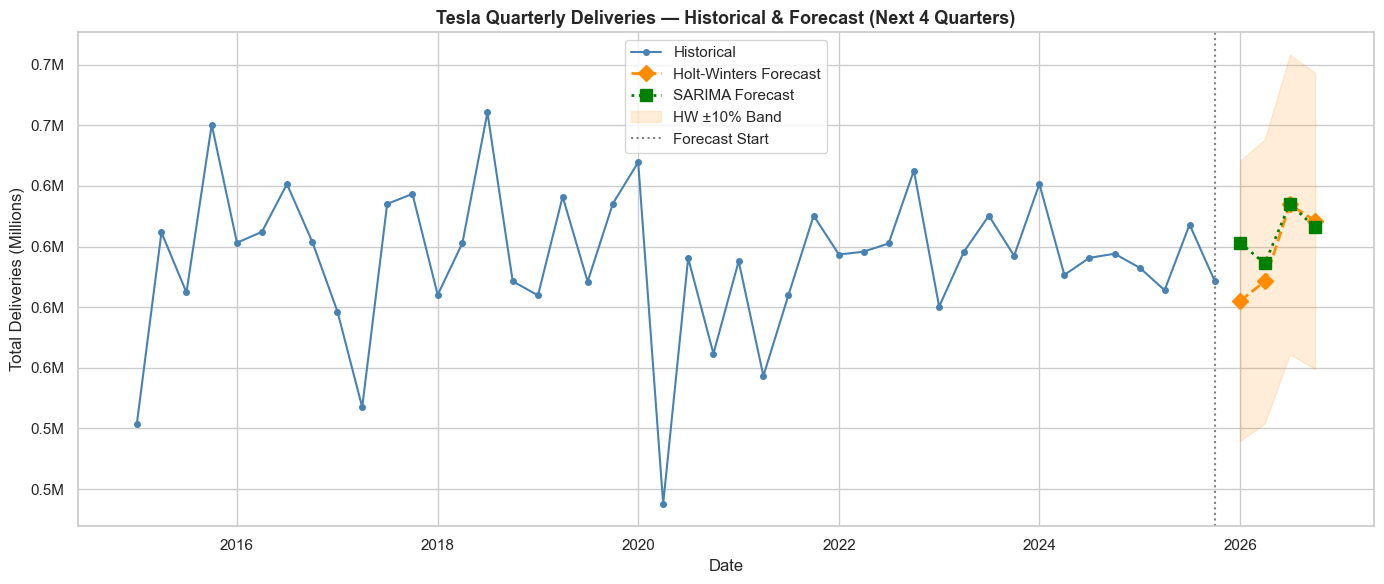

In [64]:
fig, ax = plt.subplots(figsize=(14, 6))

# Historical
ax.plot(quarterly_ts.index, quarterly_ts.values / 1e6,
        label='Historical', color='steelblue', marker='o', markersize=4, linewidth=1.5)

# Holt-Winters forecast
ax.plot(future_dates, hw_future.values / 1e6,
        label='Holt-Winters Forecast', color='darkorange',
        marker='D', markersize=8, linewidth=2, linestyle='--')

# SARIMA forecast
ax.plot(future_dates, sarima_future.values / 1e6,
        label='SARIMA Forecast', color='green',
        marker='s', markersize=8, linewidth=2, linestyle=':')

# Uncertainty band for Holt-Winters (±10%)
hw_vals = hw_future.values / 1e6
ax.fill_between(future_dates, hw_vals * 0.90, hw_vals * 1.10,
                alpha=0.15, color='darkorange', label='HW ±10% Band')

ax.axvline(quarterly_ts.index[-1], color='grey', linestyle=':', linewidth=1.5, label='Forecast Start')
ax.set_title("Tesla Quarterly Deliveries — Historical & Forecast (Next 4 Quarters)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Date")
ax.set_ylabel("Total Deliveries (Millions)")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))
plt.tight_layout()
plt.show()

**What the forecast tells us:**
- Both models expect deliveries to stay in a similar range to recent quarters — around 570,000 to 620,000 per quarter.
- Holt-Winters is more conservative and tracks recent trends closely. SARIMA picks up slightly more seasonal variation.
- The ±10% uncertainty band shows that real-world results will depend on factors the model cannot see — such as price cuts, factory issues, or changes in demand.
- For business planning, the Holt-Winters forecast is the better choice because it had a lower error (MAPE 2.16%) on the test period.

#### 14. Pipeline Summary

In [54]:
print("TESLA DELIVERIES ML PIPELINE — END-TO-END SUMMARY")
print("=" * 55)

print("\n1. DATA CLEANING")
print("   No missing values found.")
print("   No logical duplicates in Year/Month/Region/Model.")
print("   Winsorisation applied at 1st and 99th percentiles.")
print("   Date column created and data sorted by time.")

print("\n2. EXPLORATORY DATA ANALYSIS")
print("   Deliveries are right-skewed — a few combos drive high volume.")
print("   North America and Model Y contribute the most.")
print("   Q4 and quarter-end months always spike — consistent pattern.")
print("   Production Units has ~0.95 correlation with deliveries.")

print("\n3. FEATURE ENGINEERING")
print("   Calendar flags: Quarter, Is_Q4, Is_Quarter_End_Month.")
print("   Lag features: Lag3 and Lag6 (per Region-Model group).")
print("   Rolling stats: 3-month and 6-month mean and std.")
print("   Growth rates: MoM and YoY growth, price change MoM.")

print("\n4. REGRESSION MODELS")
print("   Models: Linear Regression, Ridge, Lasso.")
print("   Chronological 80/20 split (last 12 months as test).")
print("   SimpleImputer added to pipeline — no NaN errors.")
print("   Production_Units excluded — too correlated with target.")
print("   All models achieved R² ≈ 0.95 on test set.")

print("\n5. CROSS VALIDATION & TUNING")
print("   TimeSeriesSplit with 5 folds — no future data leakage.")
print("   GridSearchCV to find best alpha for Ridge and Lasso.")
print("   CV R² stable across folds (std < 0.004) — no overfitting.")

print("\n6. TIME SERIES FORECASTING")
print("   Holt-Winters: MAPE = 2.16% — excellent accuracy.")
print("   SARIMA(1,1,1)(1,1,1,4): MAPE = 4.87%.")
print("   Both models forecast next 4 quarters of global deliveries.")
print("   Holt-Winters is the recommended forecasting model.")

TESLA DELIVERIES ML PIPELINE — END-TO-END SUMMARY

1. DATA CLEANING
   No missing values found.
   No logical duplicates in Year/Month/Region/Model.
   Winsorisation applied at 1st and 99th percentiles.
   Date column created and data sorted by time.

2. EXPLORATORY DATA ANALYSIS
   Deliveries are right-skewed — a few combos drive high volume.
   North America and Model Y contribute the most.
   Q4 and quarter-end months always spike — consistent pattern.
   Production Units has ~0.95 correlation with deliveries.

3. FEATURE ENGINEERING
   Calendar flags: Quarter, Is_Q4, Is_Quarter_End_Month.
   Lag features: Lag3 and Lag6 (per Region-Model group).
   Rolling stats: 3-month and 6-month mean and std.
   Growth rates: MoM and YoY growth, price change MoM.

4. REGRESSION MODELS
   Models: Linear Regression, Ridge, Lasso.
   Chronological 80/20 split (last 12 months as test).
   SimpleImputer added to pipeline — no NaN errors.
   Production_Units excluded — too correlated with target.
   A

#### 15. Conclusions

**Key Findings:**

1. Tesla deliveries grew strongly from 2015 to 2023. The biggest jump happened from 2020 onwards, driven by Model Y and new factories.

2. Deliveries always spike at the end of each quarter (March, June, September, December). This is a consistent pattern every year, not random noise.

3. Model Y and Model 3 are responsible for most of the total delivery volume. Models S and X are lower volume.

4. Production capacity is the single biggest factor in how many vehicles get delivered. Demand alone does not drive deliveries — supply does.

5. Lag features (3 and 6 months back) are the most useful features for predicting deliveries after removing Production Units.

**Best Regression Model:**

The best regression model is the **Lasso (Tuned)** or **Ridge (Tuned)** — both achieve R² ≈ 0.95 on the held-out test set. Cross-validation R² is also stable at around 0.948 across all 5 folds, which means the model generalises well and is not overfitting.

**Best Forecasting Model:**

**Holt-Winters Exponential Smoothing** is the better time series model, with a MAPE of just 2.16% on the last 4 known quarters. It correctly captures both the upward trend and the quarterly seasonal pattern. SARIMA also works but had a higher error (4.87% MAPE).

**Next Steps:**

- Add external variables to the regression model (interest rates, competitor sales, EV incentives)
- Try tree-based models like Random Forest or XGBoost for potentially higher R²
- Use SARIMA order selection (auto-ARIMA) to automatically find better parameters
- Retrain models every quarter as new data arrives